In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning, module='lightgbm')

PROCESSED_DATA_DIR = "data/processed"
ARTIFACTS_DIR = os.path.join(PROCESSED_DATA_DIR, "model_artifacts")

df_master = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "01_cleaned_cohort.csv.gz"),
    compression='gzip'
)
df_defaults = df_master[df_master['target'] == 1].copy()
print(f"Defaulted population: {len(df_defaults):,} records")

# LGD target: fraction of loan unrecovered after default
# Basel III definition: LGD = 1 - (recoveries / EAD)


df_defaults['lgd_target'] = 1.0 - (df_defaults['recoveries'] / df_defaults['loan_amnt'])
df_defaults['lgd_target'] = np.clip(df_defaults['lgd_target'], 0.0, 1.0)

df_defaults['ead_target'] = df_defaults['loan_amnt'] - df_defaults['total_rec_prncp']
df_defaults['ead_target'] = np.clip(df_defaults['ead_target'], 0.0, df_defaults['loan_amnt'])

print(f"\nLGD target  — mean: {df_defaults['lgd_target'].mean():.3f}  std: {df_defaults['lgd_target'].std():.3f}")
print(f"EAD target  — mean: ${df_defaults['ead_target'].mean():,.0f}  std: ${df_defaults['ead_target'].std():,.0f}")

Defaulted population: 220,556 records

LGD target  — mean: 0.922  std: 0.097
EAD target  — mean: $10,639  std: $7,396


In [2]:
# Expanded feature set — the original 5-feature list is too narrow for LGD/EAD
# which is sensitive to collateral proxies and utilisation signals
ml_features = [
    'int_rate', 'annual_inc', 'dti', 'loan_amnt', 'fico_range_low',
    'revol_util', 'bc_util', 'tot_cur_bal', 'mort_acc', 'term'
]
ml_features = [f for f in ml_features if f in df_defaults.columns]

X_defaults = df_defaults[ml_features].copy()

# Convert term to numeric — must happen before train/test split and before fit
# astype(str) handles both object and pandas 3.x StringDtype safely
if 'term' in X_defaults.columns:
    X_defaults['term'] = (
        X_defaults['term'].astype(str)
                          .str.extract(r'(\d+)')[0]
                          .pipe(pd.to_numeric, errors='coerce')
    )

X_train, X_test, y_lgd_train, y_lgd_test = train_test_split(
    X_defaults, df_defaults['lgd_target'],
    test_size=0.30, random_state=42
)
_, _, y_ead_train, y_ead_test = train_test_split(
    X_defaults, df_defaults['ead_target'],
    test_size=0.30, random_state=42
)

# LGD: fractional response bounded in [0,1]; objective='regression' is appropriate
# (a true Tweedie or Beta regression would be more rigorous but is not in LightGBM natively)
lgd_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    min_child_samples=50,   # avoids overfitting on the smaller defaults population
    random_state=42,
    verbose=-1
)
lgd_model.fit(X_train, y_lgd_train)

# EAD: unbounded positive regression
ead_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    min_child_samples=50,
    random_state=42,
    verbose=-1
)
ead_model.fit(X_train, y_ead_train)

print("LGD and EAD models trained.")

LGD and EAD models trained.


=== LGD MODEL VALIDATION (out-of-sample) ===
MAE : 0.0627  (average prediction error in LGD fraction)
R²  : 0.0153

=== EAD MODEL VALIDATION (out-of-sample) ===
MAE : $2,394.80  (average prediction error in dollars)
R²  : 0.7929


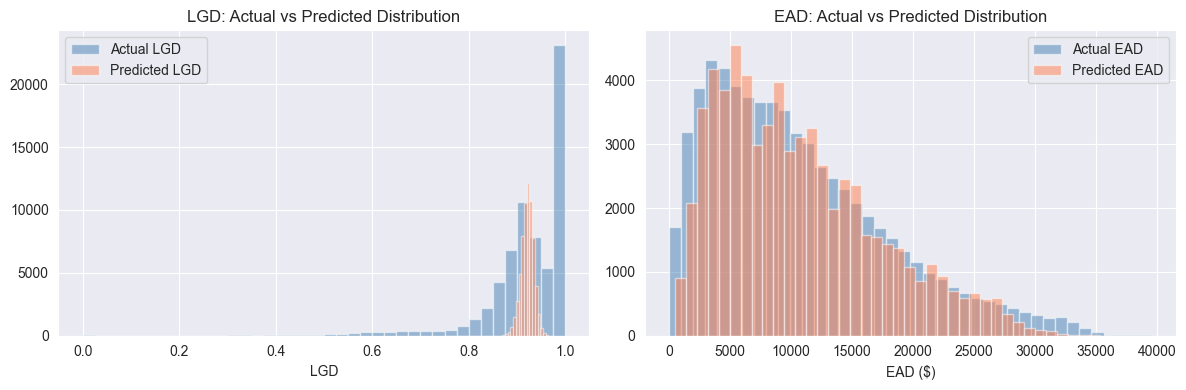


✅ LGD and EAD engines exported to model_artifacts/lgd_ead_engines.pkl


In [3]:
# --- LGD Validation ---
lgd_preds = np.clip(lgd_model.predict(X_test), 0.0, 1.0)
lgd_mae   = mean_absolute_error(y_lgd_test, lgd_preds)
lgd_r2    = r2_score(y_lgd_test, lgd_preds)

print("=== LGD MODEL VALIDATION (out-of-sample) ===")
print(f"MAE : {lgd_mae:.4f}  (average prediction error in LGD fraction)")
print(f"R²  : {lgd_r2:.4f}")

# --- EAD Validation ---
ead_preds = np.clip(ead_model.predict(X_test), 0.0, X_test['loan_amnt'])
ead_mae   = mean_absolute_error(y_ead_test, ead_preds)
ead_r2    = r2_score(y_ead_test, ead_preds)

print("\n=== EAD MODEL VALIDATION (out-of-sample) ===")
print(f"MAE : ${ead_mae:,.2f}  (average prediction error in dollars)")
print(f"R²  : {ead_r2:.4f}")

# Distribution plot: predicted vs actual — the visual most likely to be asked about in interview
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_lgd_test, bins=40, alpha=0.5, label='Actual LGD', color='steelblue')
axes[0].hist(lgd_preds,  bins=40, alpha=0.5, label='Predicted LGD', color='coral')
axes[0].set_title('LGD: Actual vs Predicted Distribution')
axes[0].set_xlabel('LGD')
axes[0].legend()

axes[1].hist(y_ead_test, bins=40, alpha=0.5, label='Actual EAD', color='steelblue')
axes[1].hist(ead_preds,  bins=40, alpha=0.5, label='Predicted EAD', color='coral')
axes[1].set_title('EAD: Actual vs Predicted Distribution')
axes[1].set_xlabel('EAD ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Export
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
with open(os.path.join(ARTIFACTS_DIR, "lgd_ead_engines.pkl"), "wb") as f:
    pickle.dump({'lgd': lgd_model, 'ead': ead_model, 'features': ml_features}, f)

print("\n✅ LGD and EAD engines exported to model_artifacts/lgd_ead_engines.pkl")